# Paso 7 - Ablation Study

Este notebook explicita el analisis de ablacion del proyecto.

Objetivo: aislar el aporte de cada componente del modelo propuesto:

- senal secuencial,
- metadata de categoria directa,
- jerarquia de categorias,
- combinacion hibrida fija,
- pesos adaptativos,
- tuning de hiperparametros.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path('..').resolve().parent
OUTPUT_DIR = PROJECT_DIR / 'H3' / 'outputs'
FIG_DIR = OUTPUT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 160)

## 1. Cargar resultados de variantes

Usamos dos fuentes:

- `step2_metrics_summary_sample_50000.csv`: contiene variantes no tuneadas evaluadas en muestra de 50.000 usuarios.
- `step2_best_model_metrics_full.csv` y `final_metrics_summary_full.csv`: contienen el modelo tuneado y baselines finales sobre todos los usuarios evaluables.

In [2]:
step2_sample = pd.read_csv(OUTPUT_DIR / 'step2_metrics_summary_sample_50000.csv')
final_full = pd.read_csv(OUTPUT_DIR / 'final_metrics_summary_full.csv')
best_full = pd.read_csv(OUTPUT_DIR / 'step2_best_model_metrics_full.csv')

display(step2_sample)
display(final_full)

,model,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10
0,Adaptive Hierarchical Hybrid,0.011274,0.11274,0.068430,13.549909,0.514987,0.298004
1,Adaptive Hybrid,0.011202,0.11202,0.068732,13.470180,0.544921,0.299436
2,Fixed Hybrid Seq+Category,0.010862,0.10862,0.068026,13.166489,0.622498,0.298820
3,Sequential Transition,0.010154,0.10154,0.065877,13.245488,0.729615,0.328835
4,Category Popularity,0.007654,0.07654,0.041117,13.504187,0.070672,0.065833
5,Hierarchical Category,0.007608,0.07608,0.040924,13.511239,0.072520,0.065581
6,Most Popular,0.000226,0.00226,0.000947,10.197979,0.955462,0.000133
7,Random,0.000004,0.00004,0.000026,18.788678,0.995118,0.963565


,model,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10
0,Adaptive Hierarchical Hybrid (tuned),0.011413,0.114127,0.069032,13.596369,0.505077,0.495391
1,Fixed Hybrid Seq+Category,0.010945,0.109453,0.068414,13.165151,0.621789,0.494210
2,Sequential Transition,0.010251,0.102515,0.066455,13.245382,0.728481,0.516679
3,ItemKNN,0.007913,0.079134,0.043888,15.419379,0.741596,0.638723
4,Category Popularity,0.007632,0.076324,0.040498,13.500720,0.070065,0.078255
5,Most Popular,0.000219,0.002194,0.000931,10.198046,0.955455,0.000265
6,Random,0.000005,0.000052,0.000021,18.787670,0.995093,1.000000


## 2. Definir variantes de ablacion

Cada fila indica que componentes estan activos. Esto permite interpretar los resultados como un analisis por componentes, no solo como una lista de modelos.

In [3]:
component_rows = [
    {
        'model': 'Sequential Transition',
        'sequential': True,
        'direct_category': False,
        'hierarchy': False,
        'fixed_weights': False,
        'adaptive_weights': False,
        'tuned': False,
        'interpretation': 'Solo usa transiciones item-item desde el historial reciente.'
    },
    {
        'model': 'Category Popularity',
        'sequential': False,
        'direct_category': True,
        'hierarchy': False,
        'fixed_weights': False,
        'adaptive_weights': False,
        'tuned': False,
        'interpretation': 'Solo usa popularidad dentro de la ultima categoria conocida.'
    },
    {
        'model': 'Hierarchical Category',
        'sequential': False,
        'direct_category': True,
        'hierarchy': True,
        'fixed_weights': False,
        'adaptive_weights': False,
        'tuned': False,
        'interpretation': 'Usa categoria directa y backoff por ancestros, sin secuencia.'
    },
    {
        'model': 'Fixed Hybrid Seq+Category',
        'sequential': True,
        'direct_category': True,
        'hierarchy': False,
        'fixed_weights': True,
        'adaptive_weights': False,
        'tuned': False,
        'interpretation': 'Combina secuencia y categoria directa con pesos fijos.'
    },
    {
        'model': 'Adaptive Hybrid',
        'sequential': True,
        'direct_category': True,
        'hierarchy': False,
        'fixed_weights': False,
        'adaptive_weights': True,
        'tuned': False,
        'interpretation': 'Combina secuencia y categoria directa con pesos adaptativos.'
    },
    {
        'model': 'Adaptive Hierarchical Hybrid',
        'sequential': True,
        'direct_category': True,
        'hierarchy': True,
        'fixed_weights': False,
        'adaptive_weights': True,
        'tuned': False,
        'interpretation': 'Combina secuencia, categoria y jerarquia con pesos adaptativos.'
    },
    {
        'model': 'Adaptive Hierarchical Hybrid (tuned)',
        'sequential': True,
        'direct_category': True,
        'hierarchy': True,
        'fixed_weights': False,
        'adaptive_weights': True,
        'tuned': True,
        'interpretation': 'Misma arquitectura adaptativa jerarquica, con hiperparametros tuneados.'
    },
]

components = pd.DataFrame(component_rows)
display(components)

,model,sequential,direct_category,hierarchy,fixed_weights,adaptive_weights,tuned,interpretation
0,Sequential Transition,True,False,False,False,False,False,Solo usa transiciones item-item desde el historial reciente.
1,Category Popularity,False,True,False,False,False,False,Solo usa popularidad dentro de la ultima categoria conocida.
2,Hierarchical Category,False,True,True,False,False,False,"Usa categoria directa y backoff por ancestros, sin secuencia."
3,Fixed Hybrid Seq+Category,True,True,False,True,False,False,Combina secuencia y categoria directa con pesos fijos.
4,Adaptive Hybrid,True,True,False,False,True,False,Combina secuencia y categoria directa con pesos adaptativos.
5,Adaptive Hierarchical Hybrid,True,True,True,False,True,False,"Combina secuencia, categoria y jerarquia con pesos adaptativos."
6,Adaptive Hierarchical Hybrid (tuned),True,True,True,False,True,True,"Misma arquitectura adaptativa jerarquica, con hiperparametros tuneados."


## 3. Tabla de ablacion en muestra de 50.000 usuarios

Esta tabla permite comparar las variantes no tuneadas bajo el mismo protocolo de muestra. Es la evidencia mas directa para aislar componentes antes del tuning final.

In [4]:
ablation_sample = components.merge(step2_sample, on='model', how='inner')
ablation_sample = ablation_sample.sort_values('recall@10', ascending=False)
ablation_sample.to_csv(OUTPUT_DIR / 'step7_ablation_sample_50000.csv', index=False)
display(ablation_sample[[
    'model', 'sequential', 'direct_category', 'hierarchy', 'fixed_weights', 'adaptive_weights',
    'precision@10', 'recall@10', 'ndcg@10', 'novelty@10', 'category_diversity@10', 'catalog_coverage@10',
    'interpretation'
]])

,model,sequential,direct_category,hierarchy,fixed_weights,adaptive_weights,precision@10,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10,interpretation
5,Adaptive Hierarchical Hybrid,True,True,True,False,True,0.011274,0.11274,0.068430,13.549909,0.514987,0.298004,"Combina secuencia, categoria y jerarquia con pesos adaptativos."
4,Adaptive Hybrid,True,True,False,False,True,0.011202,0.11202,0.068732,13.470180,0.544921,0.299436,Combina secuencia y categoria directa con pesos adaptativos.
3,Fixed Hybrid Seq+Category,True,True,False,True,False,0.010862,0.10862,0.068026,13.166489,0.622498,0.298820,Combina secuencia y categoria directa con pesos fijos.
0,Sequential Transition,True,False,False,False,False,0.010154,0.10154,0.065877,13.245488,0.729615,0.328835,Solo usa transiciones item-item desde el historial reciente.
1,Category Popularity,False,True,False,False,False,0.007654,0.07654,0.041117,13.504187,0.070672,0.065833,Solo usa popularidad dentro de la ultima categoria conocida.
2,Hierarchical Category,False,True,True,False,False,0.007608,0.07608,0.040924,13.511239,0.072520,0.065581,"Usa categoria directa y backoff por ancestros, sin secuencia."


## 4. Tabla de ablacion final con modelo tuneado

La tabla final mezcla resultados full de los baselines principales con el modelo tuneado. Para `Adaptive Hybrid` y `Adaptive Hierarchical Hybrid` no tuneados conservamos la evidencia de muestra; para el resultado final reportamos la corrida full.

In [5]:
full_models = final_full[final_full['model'].isin([
    'Sequential Transition',
    'Category Popularity',
    'Fixed Hybrid Seq+Category',
    'Adaptive Hierarchical Hybrid (tuned)',
])].copy()

sample_only = step2_sample[step2_sample['model'].isin([
    'Hierarchical Category',
    'Adaptive Hybrid',
    'Adaptive Hierarchical Hybrid',
])].copy()
sample_only['evaluation_scope'] = 'sample_50000'
full_models['evaluation_scope'] = 'full_406020'

ablation_mixed = pd.concat([full_models, sample_only], ignore_index=True)
ablation_mixed = components.merge(ablation_mixed, on='model', how='inner')
ablation_mixed = ablation_mixed.sort_values(['evaluation_scope', 'recall@10'], ascending=[True, False])
ablation_mixed.to_csv(OUTPUT_DIR / 'step7_ablation_mixed_final.csv', index=False)
display(ablation_mixed[[
    'model', 'evaluation_scope', 'sequential', 'direct_category', 'hierarchy', 'fixed_weights',
    'adaptive_weights', 'tuned', 'recall@10', 'ndcg@10', 'novelty@10', 'category_diversity@10',
    'catalog_coverage@10', 'interpretation'
]])

,model,evaluation_scope,sequential,direct_category,hierarchy,fixed_weights,adaptive_weights,tuned,recall@10,ndcg@10,novelty@10,category_diversity@10,catalog_coverage@10,interpretation
6,Adaptive Hierarchical Hybrid (tuned),full_406020,True,True,True,False,True,True,0.114127,0.069032,13.596369,0.505077,0.495391,"Misma arquitectura adaptativa jerarquica, con hiperparametros tuneados."
3,Fixed Hybrid Seq+Category,full_406020,True,True,False,True,False,False,0.109453,0.068414,13.165151,0.621789,0.494210,Combina secuencia y categoria directa con pesos fijos.
0,Sequential Transition,full_406020,True,False,False,False,False,False,0.102515,0.066455,13.245382,0.728481,0.516679,Solo usa transiciones item-item desde el historial reciente.
1,Category Popularity,full_406020,False,True,False,False,False,False,0.076324,0.040498,13.500720,0.070065,0.078255,Solo usa popularidad dentro de la ultima categoria conocida.
5,Adaptive Hierarchical Hybrid,sample_50000,True,True,True,False,True,False,0.112740,0.068430,13.549909,0.514987,0.298004,"Combina secuencia, categoria y jerarquia con pesos adaptativos."
4,Adaptive Hybrid,sample_50000,True,True,False,False,True,False,0.112020,0.068732,13.470180,0.544921,0.299436,Combina secuencia y categoria directa con pesos adaptativos.
2,Hierarchical Category,sample_50000,False,True,True,False,False,False,0.076080,0.040924,13.511239,0.072520,0.065581,"Usa categoria directa y backoff por ancestros, sin secuencia."


## 5. Grafico de ablacion: Recall@10 y nDCG@10

El objetivo es visualizar como cambia la relevancia al agregar componentes.

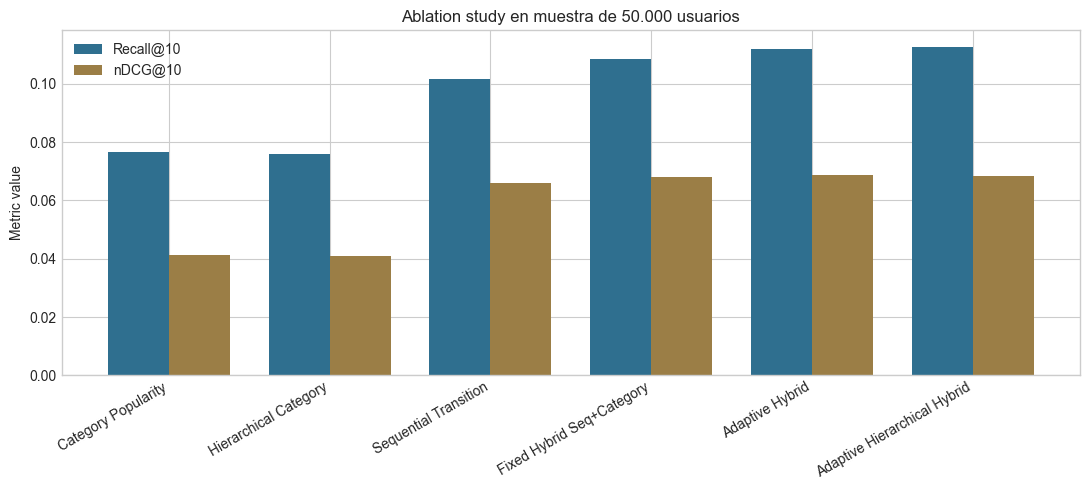

In [6]:
plot_order = [
    'Category Popularity',
    'Hierarchical Category',
    'Sequential Transition',
    'Fixed Hybrid Seq+Category',
    'Adaptive Hybrid',
    'Adaptive Hierarchical Hybrid',
]
plot_df = ablation_sample.set_index('model').loc[plot_order].reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width/2, plot_df['recall@10'], width, label='Recall@10', color='#2f6f8f')
ax.bar(x + width/2, plot_df['ndcg@10'], width, label='nDCG@10', color='#9b7e46')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['model'], rotation=30, ha='right')
ax.set_title('Ablation study en muestra de 50.000 usuarios')
ax.set_ylabel('Metric value')
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'step7_ablation_recall_ndcg_sample.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Mejoras por componente

Calculamos diferencias entre variantes cercanas para cuantificar el aporte de cada bloque.

In [7]:
sample_idx = step2_sample.set_index('model')

comparisons = [
    ('Categoria directa vs secuencial', 'Category Popularity', 'Sequential Transition'),
    ('Jerarquia sobre categoria directa', 'Category Popularity', 'Hierarchical Category'),
    ('Hibrido fijo sobre secuencial', 'Sequential Transition', 'Fixed Hybrid Seq+Category'),
    ('Adaptacion sobre hibrido fijo', 'Fixed Hybrid Seq+Category', 'Adaptive Hybrid'),
    ('Jerarquia sobre adaptativo', 'Adaptive Hybrid', 'Adaptive Hierarchical Hybrid'),
]

delta_rows = []
for label, base, variant in comparisons:
    for metric in ['recall@10', 'ndcg@10', 'novelty@10', 'category_diversity@10', 'catalog_coverage@10']:
        base_value = sample_idx.loc[base, metric]
        variant_value = sample_idx.loc[variant, metric]
        delta_rows.append({
            'comparison': label,
            'base_model': base,
            'variant_model': variant,
            'metric': metric,
            'base_value': base_value,
            'variant_value': variant_value,
            'absolute_delta': variant_value - base_value,
            'relative_delta': (variant_value - base_value) / base_value if base_value != 0 else np.nan,
        })

component_deltas = pd.DataFrame(delta_rows)
component_deltas.to_csv(OUTPUT_DIR / 'step7_component_deltas_sample_50000.csv', index=False)
display(component_deltas)

,comparison,base_model,variant_model,metric,base_value,variant_value,absolute_delta,relative_delta
0,Categoria directa vs secuencial,Category Popularity,Sequential Transition,recall@10,0.076540,0.101540,0.025000,0.326627
1,Categoria directa vs secuencial,Category Popularity,Sequential Transition,ndcg@10,0.041117,0.065877,0.024760,0.602172
2,Categoria directa vs secuencial,Category Popularity,Sequential Transition,novelty@10,13.504187,13.245488,-0.258699,-0.019157
3,Categoria directa vs secuencial,Category Popularity,Sequential Transition,category_diversity@10,0.070672,0.729615,0.658942,9.323894
4,Categoria directa vs secuencial,Category Popularity,Sequential Transition,catalog_coverage@10,0.065833,0.328835,0.263002,3.994963
5,Jerarquia sobre categoria directa,Category Popularity,Hierarchical Category,recall@10,0.076540,0.076080,-0.000460,-0.006010
6,Jerarquia sobre categoria directa,Category Popularity,Hierarchical Category,ndcg@10,0.041117,0.040924,-0.000193,-0.004695
7,Jerarquia sobre categoria directa,Category Popularity,Hierarchical Category,novelty@10,13.504187,13.511239,0.007052,0.000522
8,Jerarquia sobre categoria directa,Category Popularity,Hierarchical Category,category_diversity@10,0.070672,0.072520,0.001847,0.026136
9,Jerarquia sobre categoria directa,Category Popularity,Hierarchical Category,catalog_coverage@10,0.065833,0.065581,-0.000252,-0.003828


## 7. Lectura del ablation study

Conclusiones principales:

- La senal secuencial es mas fuerte que la categoria directa por si sola.
- La categoria directa contiene informacion util, pero no basta para superar a la senal secuencial.
- El hibrido fijo mejora a los modelos individuales, lo que indica complementariedad entre secuencia y categoria.
- Los pesos adaptativos mejoran al hibrido fijo, especialmente en Recall@10.
- La jerarquia agrega una mejora adicional pequena en Recall@10 sobre el hibrido adaptativo sin jerarquia.
- El tuning final entrega la mejor version del modelo propuesto en la evaluacion full.